# Siamese architecture

In [ ]:
# This file was used to debug or try the code locally before we sent it to metacentrum.
# Thats why there are some errors under the cells.

## Load data

In [1]:
import tensorflow as tf
import os
import numpy as np
# Should help to avoid OOM errors
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
# Load data for pairs creation
original_dir = os.path.join('data', 'Original')
deepfake_dir = os.path.join('data', 'Deepfake')

In [3]:
# List all files in the directories
original_files = [os.path.join(original_dir, f) for f in os.listdir(original_dir)]
deepfake_files = [os.path.join(deepfake_dir, f) for f in os.listdir(deepfake_dir)]
print(len(deepfake_files))
print(len(original_files))

4900
1400


In [6]:
# Pairs creation for siamese network
# Original vs Deepfake of Original (Label 1)
pairs = []
labels = []
count = 0
for original_file in original_files:
    filename = os.path.basename(original_file)
    index = filename.split('_')[1].split('.')[0]
    
    # Path for deepfakes
    deepfake_file1 = os.path.join(deepfake_dir, f'Deep1_{index}.jpg')
    deepfake_file2 = os.path.join(deepfake_dir, f'Deep2_{index}.jpg')
    deepfake_file3 = os.path.join(deepfake_dir, f'Deep3_{index}.jpg')
    deepfake_file4 = os.path.join(deepfake_dir, f'Deep4_{index}.jpg')
    
    if deepfake_file3 in deepfake_files:
        pairs.append((original_file, deepfake_file3))
        labels.append(1)
        
    if deepfake_file1 in deepfake_files and deepfake_file2 in deepfake_files and deepfake_file4 in deepfake_files:
        pairs.append((original_file, deepfake_file1))
        labels.append(1)  # 1 for similar pairs (original and deepfake)
        
        pairs.append((original_file, deepfake_file2))
        labels.append(1)  # 1 for similar pairs (original and deepfake)

        pairs.append((original_file, deepfake_file4))
print(len(pairs))

4200


In [5]:
# Creation of pairs as label 0
# Original vs. Deepfake of Another Person (Label 0)
index = 700 # As was mentioned the third deepfake program ghost, do not have data from dataset CelebA HQ
for original_file in original_files:
    filename = os.path.basename(original_file)

    deepfake_file3 = os.path.join(deepfake_dir, f'Deep3_{index}.jpg')

    if deepfake_file3 in deepfake_files:
        pairs.append((original_file, deepfake_file3))
        labels.append(0)
    index -= 1

index = 1400
for original_file in original_files:
    filename = os.path.basename(original_file)
    
    deepfake_file1 = os.path.join(deepfake_dir, f'Deep1_{index}.jpg')
    deepfake_file2 = os.path.join(deepfake_dir, f'Deep2_{index}.jpg')
    deepfake_file4 = os.path.join(deepfake_dir, f'Deep4_{index}.jpg')
    
    if deepfake_file1 in deepfake_files and deepfake_file2 in deepfake_files and deepfake_file4 in deepfake_files:
        pairs.append((original_file, deepfake_file1))
        labels.append(0)  # 0 for dissimilar pairs (original and deepfake of another person)

        pairs.append((original_file, deepfake_file2))
        labels.append(0)  # 0 for dissimilar pairs (original and deepfake of another person)

        pairs.append((original_file, deepfake_file4))
        labels.append(0)
    index -= 1
print(len(pairs))

9100


In [6]:
# Original vs. Original (Label 0)
count = 0
for original_file in original_files:
    pairs.append((original_file, original_file))
    labels.append(0)  # 0 for dissimilar pairs (original vs. original)

print(len(pairs))

11200


Label 1


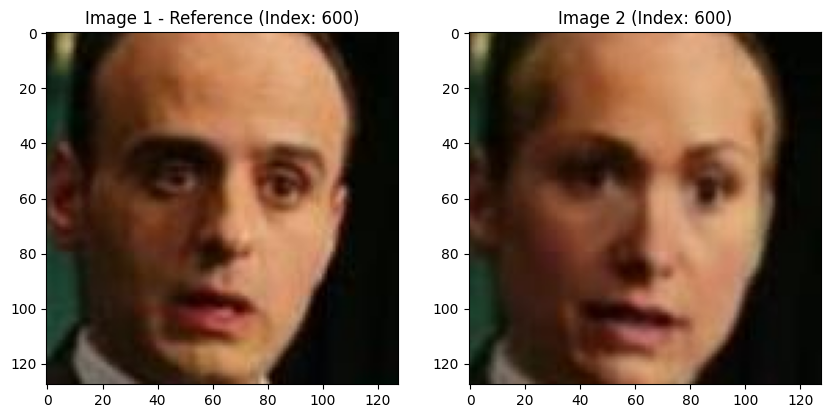

Label 1


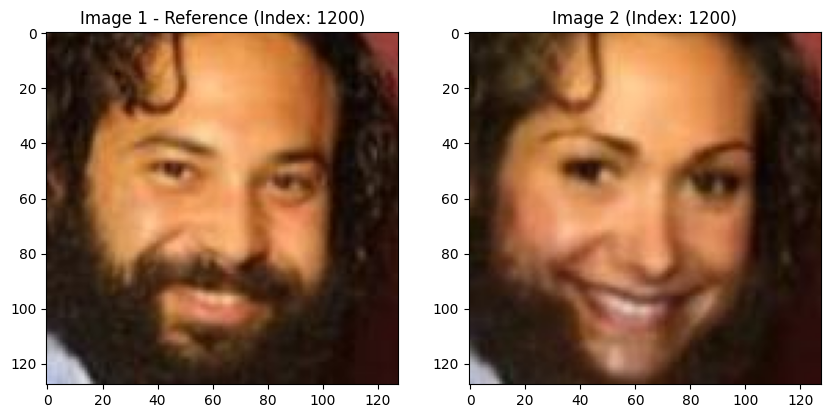

Label 1


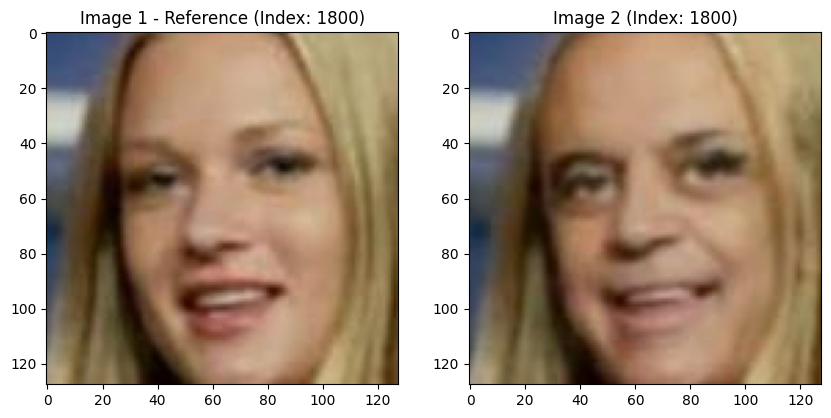

Label 0


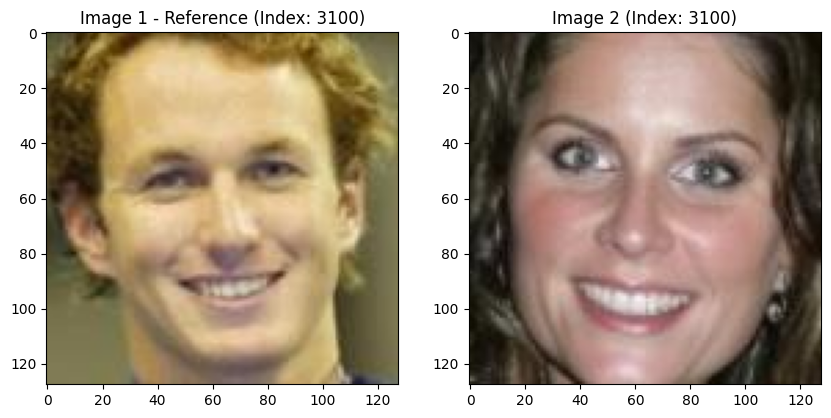

In [34]:
# Checking if it is done correctly with visualization
indices = [600, 1200, 1800, 3100]

for i, idx in enumerate(indices, start=1):
    print('Label',labels[idx])
    plt.figure(figsize=(10, 5))
    
    original_img = mpimg.imread(pairs[idx][0])
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title(f'Image 1 - Reference (Index: {idx})')

    deepfake_img = mpimg.imread(pairs[idx][1])
    plt.subplot(1, 2, 2)
    plt.imshow(deepfake_img)
    plt.title(f'Image 2 (Index: {idx})')

    plt.show()

## Scale and split of + shuffle 

In [7]:
# Procesing image with tf functions and transform to (0,1)
def preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32) / 255.0
    return img

# Preparing pairs for convertion to numpy array
def load_and_preprocess_pairs(pairs):
    scaled_pairs = []
    for pair in pairs:
        img1 = preprocess_image(pair[0])
        img2 = preprocess_image(pair[1])
        scaled_pairs.append((img1, img2))
    return scaled_pairs

scaled_pairs = load_and_preprocess_pairs(pairs)

# Convert scaled_pairs to numpy array
scaled_pairs = np.array(scaled_pairs)
labels = np.array(labels)

# Train: 70 % | Validation: 20 % | Test: The remaining images
train_size = int(len(scaled_pairs) * 0.7)
val_size = int(len(scaled_pairs) * 0.2)
test_size = len(scaled_pairs) - train_size - val_size

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (4200, 2) + inhomogeneous part.

In [ ]:
shuffle_idx = np.arange(len(scaled_pairs))
np.random.shuffle(shuffle_idx)

scaled_pairs = scaled_pairs[shuffle_idx]
labels = labels[shuffle_idx]

In [ ]:
train_pairs, remaining_pairs = scaled_pairs[:train_size], scaled_pairs[train_size:]
val_pairs, test_pairs = remaining_pairs[:val_size], remaining_pairs[val_size:]
train_labels, val_labels, test_labels = labels[:train_size], labels[train_size:train_size+val_size], labels[train_size+val_size:]

train_data = tf.data.Dataset.from_tensor_slices((train_pairs, train_labels))
val_data = tf.data.Dataset.from_tensor_slices((val_pairs, val_labels))
test_data = tf.data.Dataset.from_tensor_slices((test_pairs, test_labels))

batch_size = 2 # Lower batch size because the computing source locally was not enough to run this configuration
train_data = train_data.shuffle(buffer_size=len(train_pairs)).batch(batch_size)
val_data = val_data.batch(batch_size)
test_data = test_data.batch(batch_size)

## Build of CNN

In [ ]:
# This model is based on science article: https://www.cs.cmu.edu/~rsalakhu/papers/oneshot1.pdf
# And the implementation in python which is also based on article above: https://medium.com/@prabhattgs12345789/siamese-neural-network-enhancing-ai-capabilities-with-pairwise-comparisons-4f00e2dd8256
# I just used the structure of model and mainly kept the number of neurons at dense layer, even tried the model they are showing. 
# Its performance was medium so i then modified it to use vgg-net

# The model is reduced in number of neurons as i said i was not able to run it locally. In the files is also python file from metacentrum which has the whole implementation which was used
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Dense, Flatten, Concatenate, Input, Layer
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Lambda
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers

def custom_model(inputs):
    vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

    for layer in vgg_model.layers:
        layer.trainable = False
    # inputs = Input(shape=(128,128,3))
    pair1 = input_pairs[:, 0, :, :, :]
    pair2 = input_pairs[:, 1, :, :, :]

    vgg_output_1 = vgg_model(pair1)
    flatten1 = Flatten()(vgg_output_1)
    dense1 = Dense(128, activation='sigmoid')(flatten1)

    vgg_output_2 = vgg_model(pair2)
    flatten2 = Flatten()(vgg_output_2)
    dense2 = Dense(128, activation='sigmoid')(flatten2)

    distance = Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([dense1, dense2]) #tf.abs(dense1 - dense2)
    return distance

In [ ]:
# Create siamese model architecture
input_pairs = tf.keras.layers.Input(shape=(2, 128, 128, 3))

distance = custom_model(input_pairs)

output = Dense(1, activation='sigmoid')(distance)

In [ ]:
# Create siamese model
siamese_model = Model(inputs=input_pairs, outputs=output)

siamese_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

siamese_model.summary()

# Load the siamese model from metacentrum

In [3]:
from keras.optimizers import Adam

# Setting optimizer
optimizer = Adam(learning_rate=1e-4)

# Defining the contrastive loss function
def contrastive_loss(y_true, y_pred):
     margin = 1.0
     y_true = tf.cast(y_true, tf.float32)
     square_predict = tf.square(y_pred)

     loss = tf.reduce_mean((1 - y_true) * square_predict + 
                           y_true * tf.square(tf.maximum(0.0, margin - y_pred)))
    
     return loss 

from tensorflow.keras.models import load_model
# Here the model was loaded. It is compiled again because the metacentrum do not provided
# version of tensorflow library, which we had locally so thats why
new_model = load_model('models/siamese_model_none_cross_19.h5', compile=False)

# There are two possibilities. To use contrastive loss or binary crossenthropy.
new_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy']) #contrastive_loss,  'binary_crossentropy'

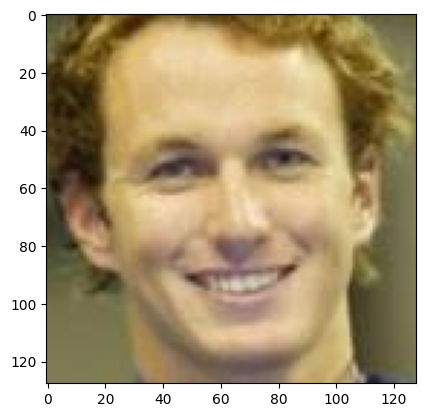

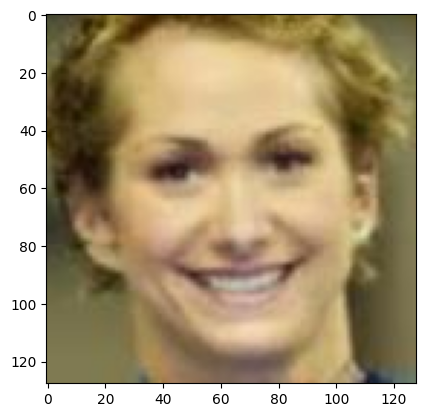

In [2]:
# This was the approach with cv2 library which was used most of the time. Near the later part of the thesis we changed
# cv2 to PIL library, because it had so much better results.
# But we will leave it here as example

from matplotlib import pyplot as plt
import cv2
img1 = cv2.imread('siam_test_data/Origin_4.jpg')
img2 = cv2.imread('siam_test_data/Deep1_4.jpg')
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.show()

In [3]:
import numpy as np
img1 = img1.astype('float32') / 255.0
img2 = img2.astype('float32') / 255.0
image_pair = np.stack([img1, img2], axis=0)  # Shape: (2, 128, 128, 3)

predictions = new_model.predict(np.expand_dims(image_pair, axis=0))

1/1 [==============================] - 6s 6s/step


In [4]:
evaluation = predictions[0][0]
print("Result:", evaluation)
print("Pred:",predictions)

if evaluation >= 0.5:
    print("The image is deepfake.")
else:
    print("The image is not deepfake.")

Result: 0.8712257
Pred: [[0.8712257]]
The image is deepfake.


# Changed evaluation with PIL library

In [26]:
# It is almost same code as before, only difference is in library and some small changes to make it runable.
from PIL import Image
from matplotlib import pyplot as plt
import cv2
img1 = Image.open('siam_test_data/Origin_4.jpg')
img2 = Image.open('siam_test_data/Deep1_4.jpg')

In [27]:
import numpy as np
img1 = np.array(img1, dtype='float32') / 255.0
img2 = np.array(img2, dtype='float32') / 255.0
image_pair = np.stack([img1, img2], axis=0)  # Shape: (2, 128, 128, 3)

predictions = new_model.predict(np.expand_dims(image_pair, axis=0))

evaluation = predictions[0][0]
print("Result:", evaluation)
print("Pred:",predictions)

if evaluation >= 0.5:
    print("The image is deepfake.")
else:
    print("The image is not deepfake.")

1/1 [==============================] - 0s 321ms/step
Result: 0.9563959
Pred: [[0.9563959]]
The image is deepfake.


# Evaluation of the results for the tables in thesis

In [7]:
# Code is very similar to the one for vgg network which used only one image on output.
# It loads as the first input reference and second is potential deepfake image
# Next it normalize it and makes prediction. According to the results we make 
# ratio of correctly predicted deepfakes or original images, depends what we want to achieve

# Roop images evaluation

from PIL import Image
import numpy as np

count = 0
for index in range(1, 101):  # Adjusted range to start from 1 and end at 100 (inclusive)
    img1 = Image.open(f'data/Original/Origin_{index}.jpg')
    img2 = Image.open(f'data/Deepfake/Deep1_{index}.jpg')

    # Check if images are successfully loaded
    if img1 is None or img2 is None:
        print(f"Failed to load images for index {index}")
        continue  # Skip to the next index if image loading fails

    img1 = np.array(img1, dtype='float32') / 255.0
    img2 = np.array(img2, dtype='float32') / 255.0
    image_pair = np.stack([img1, img2], axis=0)  # Shape: (2, 128, 128, 3)

    predictions = new_model.predict(np.expand_dims(image_pair, axis=0))
    evaluation = predictions[0][0]

    if evaluation >= 0.5:
        count += 1

ratio1 = count / 100

print("Ratio of predicted deepfakes:", ratio1)

#Fin
#Ratio of predicted deepfakes: 0.82 siamese_model_ima_cross_16
#Ratio of predicted deepfakes: 0.81 siamese_model_ima_contrast_16
#Ratio of predicted deepfakes: 0.87 siamese_model_none_cross_16
#Ratio of predicted deepfakes: 0.85 siamese_model_none_contrast_16

#Ratio of predicted deepfakes: 0.77 siamese_model_ima_cross_19
#Ratio of predicted deepfakes: 0.62 siamese_model_ima_contrast_19
#Ratio of predicted deepfakes: 0.80 siamese_model_none_cross_19
#Ratio of predicted deepfakes: 0.75 siamese_model_none_contrast_19

1/1 [==============================] - 0s 27ms/step
Ratio of predicted deepfakes: 0.6485714285714286


In [8]:
# FaceFusion images evaluation

from PIL import Image
import numpy as np

count = 0
for index in range(1, 101):  # Adjusted range to start from 1 and end at 100 (inclusive)
    img1 = Image.open(f'data/Original/Origin_{index}.jpg')
    img2 = Image.open(f'data/Deepfake/Deep2_{index}.jpg')

    if img1 is None or img2 is None:
        print(f"Failed to load images for index {index}")
        continue

    img1 = np.array(img1, dtype='float32') / 255.0
    img2 = np.array(img2, dtype='float32') / 255.0
    image_pair = np.stack([img1, img2], axis=0)

    predictions = new_model.predict(np.expand_dims(image_pair, axis=0))
    evaluation = predictions[0][0]

    if evaluation >= 0.5:
        count += 1

ratio1 = count / 100

print("Ratio of predicted deepfakes:", ratio1)

#Fin
#Ratio of predicted deepfakes: 0.62 siamese_model_ima_cross_16
#Ratio of predicted deepfakes: 0.67 siamese_model_ima_contrast_16
#Ratio of predicted deepfakes: 0.68 siamese_model_none_cross_16
#Ratio of predicted deepfakes: 0.67 siamese_model_none_contrast_16

#Ratio of predicted deepfakes: 0.65 siamese_model_ima_cross_19
#Ratio of predicted deepfakes: 0.48 siamese_model_ima_contrast_19
#Ratio of predicted deepfakes: 0.67 siamese_model_none_cross_19
#Ratio of predicted deepfakes: 0.61 siamese_model_none_contrast_19

1/1 [==============================] - 0s 24ms/step
Ratio of predicted deepfakes: 0.6285714285714286


In [30]:
# Ghost images evaluation

from PIL import Image
import numpy as np

count = 0
for index in range(1, 51):  # Adjusted range to start from 1 and end at 50 (inclusive)
    img1 = Image.open(f'data/Original/Origin_{index}.jpg')
    img2 = Image.open(f'data/Deepfake/Deep3_{index}.jpg')

    if img1 is None or img2 is None:
        print(f"Failed to load images for index {index}")
        continue

    img1 = np.array(img1, dtype='float32') / 255.0
    img2 = np.array(img2, dtype='float32') / 255.0
    image_pair = np.stack([img1, img2], axis=0)

    predictions = new_model.predict(np.expand_dims(image_pair, axis=0))
    evaluation = predictions[0][0]

    if evaluation >= 0.5:
        count += 1

ratio1 = count / 50
print("Ratio of predicted deepfakes:", ratio1)

#Fin
#Ratio of predicted deepfakes: 0.60 siamese_model_ima_cross_16
#Ratio of predicted deepfakes: 0.64 siamese_model_ima_contrast_16
#Ratio of predicted deepfakes: 0.66 siamese_model_none_cross_16
#Ratio of predicted deepfakes: 0.64 siamese_model_none_contrast_16

#Ratio of predicted deepfakes: 0.52 siamese_model_ima_cross_19
#Ratio of predicted deepfakes: 0.34 siamese_model_ima_contrast_19
#Ratio of predicted deepfakes: 0.52 siamese_model_none_cross_19
#Ratio of predicted deepfakes: 0.54 siamese_model_none_contrast_19

1/1 [==============================] - 0s 122ms/step
Ratio of predicted deepfakes: 0.9985714285714286


In [9]:
# SimSwap images evaluation

from PIL import Image
import numpy as np

count = 0
for index in range(1, 101):  # Adjusted range to start from 1 and end at 100 (inclusive)
    img1 = Image.open(f'data/Original/Origin_{index}.jpg')
    img2 = Image.open(f'data/Deepfake/Deep4_{index}.jpg')

    if img1 is None or img2 is None:
        print(f"Failed to load images for index {index}")
        continue

    img1 = np.array(img1, dtype='float32') / 255.0
    img2 = np.array(img2, dtype='float32') / 255.0
    image_pair = np.stack([img1, img2], axis=0)

    predictions = new_model.predict(np.expand_dims(image_pair, axis=0))
    evaluation = predictions[0][0]

    if evaluation >= 0.5:
        count += 1

ratio1 = count / 100

print("Ratio of predicted deepfakes:", ratio1)

#Fin
#Ratio of predicted deepfakes: 0.44 siamese_model_ima_cross_16
#Ratio of predicted deepfakes: 0.56 siamese_model_ima_contrast_16
#Ratio of predicted deepfakes: 0.57 siamese_model_none_cross_16
#Ratio of predicted deepfakes: 0.53 siamese_model_none_contrast_16

#Ratio of predicted deepfakes: 0.67 siamese_model_ima_cross_19
#Ratio of predicted deepfakes: 0.49 siamese_model_ima_contrast_19
#Ratio of predicted deepfakes: 0.68 siamese_model_none_cross_19
#Ratio of predicted deepfakes: 0.68 siamese_model_none_contrast_19

1/1 [==============================] - 0s 20ms/step
Ratio of predicted deepfakes: 0.5242857142857142


In [32]:
# Original images evaluation

from PIL import Image
import numpy as np

count = 0
for index in range(1, 101):  # Adjusted range to start from 1 and end at 100 (inclusive)
    img1 = Image.open(f'data/Original/Origin_{index}.jpg')
    img2 = Image.open(f'data/Original/Origin_{index}.jpg')

    if img1 is None or img2 is None:
        print(f"Failed to load images for index {index}")
        continue

    img1 = np.array(img1, dtype='float32') / 255.0
    img2 = np.array(img2, dtype='float32') / 255.0
    image_pair = np.stack([img1, img2], axis=0)

    predictions = new_model.predict(np.expand_dims(image_pair, axis=0))
    evaluation = predictions[0][0]

    if evaluation >= 0.5:
        count += 1

ratio1 = (100-count) / 100

print("Ratio of predicted originals:", ratio1)

#Fin
#Ratio of predicted deepfakes: 0.72 siamese_model_ima_cross_16
#Ratio of predicted deepfakes: 0.70 siamese_model_ima_contrast_16
#Ratio of predicted deepfakes: 0.67 siamese_model_none_cross_16
#Ratio of predicted deepfakes: 0.69 siamese_model_none_contrast_16

#Ratio of predicted deepfakes: 0.71 siamese_model_ima_cross_19
#Ratio of predicted deepfakes: 0.87 siamese_model_ima_contrast_19
#Ratio of predicted deepfakes: 0.70 siamese_model_none_cross_19
#Ratio of predicted deepfakes: 0.73 siamese_model_none_contrast_19

1/1 [==============================] - 0s 140ms/step
Ratio of predicted originals: 0.9914285714285714
Ratio of predicted originals: 0.9985714285714286


# Evaluation of the results for the tables in facial recognition experiments

In [ ]:
# Real1 Real2 evaluation

from PIL import Image
import numpy as np

count = 0
for index in range(1, 201):
    img1 = Image.open(f'datas/roztriedene/{index}/CFP_1.jpg')
    img2 = Image.open(f'datas/roztriedene/{index}/CFP_2.jpg')

    if img1 is None or img2 is None:
        print(f"Failed to load images for index {index}")
        continue

    img1 = np.array(img1, dtype='float32') / 255.0
    img2 = np.array(img2, dtype='float32') / 255.0
    image_pair = np.stack([img1, img2], axis=0)

    predictions = new_model.predict(np.expand_dims(image_pair, axis=0))
    evaluation = predictions[0][0]
    print(evaluation)
    if evaluation >= 0.5:
        count += 1

ratio1 = (200-count) / 200

print("Accuracy:", ratio1)

# Accuracy: 0.89

In [ ]:
# Real1 Fake evaluation

from PIL import Image
import numpy as np

count = 0
for index in range(1, 201):
    img1 = Image.open(f'datas/roztriedene/{index}/CFP_1.jpg')
    img2 = Image.open(f'datas/roztriedene/{index}/Deep_2.jpg')

    if img1 is None or img2 is None:
        print(f"Failed to load images for index {index}")
        continue

    img1 = np.array(img1, dtype='float32') / 255.0
    img2 = np.array(img2, dtype='float32') / 255.0
    image_pair = np.stack([img1, img2], axis=0)

    predictions = new_model.predict(np.expand_dims(image_pair, axis=0))
    evaluation = predictions[0][0]

    print(evaluation)
    if evaluation >= 0.5:
        count += 1

ratio1 = count / 200

print("Accuracy:", ratio1)

# Accuracy: 0.565

In [ ]:
# Real2 Fake evaluation

from PIL import Image
import numpy as np

count = 0
for index in range(1, 201):
    img1 = Image.open(f'datas/roztriedene/{index}/CFP_2.jpg')
    img2 = Image.open(f'datas/roztriedene/{index}/Deep_2.jpg')

    if img1 is None or img2 is None:
        print(f"Failed to load images for index {index}")
        continue

    img1 = np.array(img1, dtype='float32') / 255.0
    img2 = np.array(img2, dtype='float32') / 255.0
    image_pair = np.stack([img1, img2], axis=0)

    predictions = new_model.predict(np.expand_dims(image_pair, axis=0))
    evaluation = predictions[0][0]

    print(evaluation)
    if evaluation >= 0.5:
        count += 1

ratio1 = count / 200

print("Accuracy:", ratio1)

# Accuracy: 0.915